In [1]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import json
import ast

In [2]:
# Define a function to convert the string representation of an array/list
def string_to_array(array_string):
    try:
        # Use ast.literal_eval to safely evaluate the string as a Python literal
        return ast.literal_eval(array_string)
    except (ValueError, SyntaxError):
        # Handle cases where the string might not be a valid list/array string
        return array_string # Or some default/error value

In [3]:
exp_filepath = "exp_data/nopinn_ablation_nopayload_test/basic_test.csv"

df = pd.read_csv(exp_filepath, converters={'base_cmd': string_to_array,
                                           'base_pose': string_to_array,
                                           'base_rpy': string_to_array,
                                           'dof_pose': string_to_array,
                                           'base_lin_vel': string_to_array,
                                           'base_ang_vel': string_to_array,
                                           'dof_vel': string_to_array,
                                           'proj_grav': string_to_array,
                                           'feet_pos': string_to_array,
                                           'tau_act': string_to_array,
                                           'grf': string_to_array,
                                           'q_des': string_to_array,
                                           'tau_ff': string_to_array,
                                           'tau_pd': string_to_array,
                                           'failure': string_to_array})

In [4]:
# Joint tracking / violation metrics
q_actions      = np.array(df["q_des"].to_list())
q_observations = np.array(df["dof_pose"].to_list())

# cmd tracking metrics
vel_cmds = np.array(df["base_cmd"].to_list())  # v_x, v_y, w_yaw
lin_vel  = np.array(df["base_lin_vel"].to_list())
ang_vel  = np.array(df["base_ang_vel"].to_list())   # stability via roll/pitch angular velo.

# Height tracking metric
base_pose = np.array(df["base_pose"].to_list())

# Oreintation
proj_grav = np.array(df["proj_grav"].to_list())

# joint power metric
q_vel = np.array(df["dof_vel"].to_list())
q_tau = np.array(df["tau_act"].to_list())

# alignment metric, ratio metric
ff_tau = np.array(df["tau_ff"].to_list())
pd_tau = np.array(df["tau_pd"].to_list())

joint_limits = np.array([[-1.047, -0.633, -2.721, -1.047, -0.633, -2.721, -1.047, -0.633, -2.721, -1.047, -0.633, -2.721],
                         [1.047, 2.966, -0.837, 1.047, 2.966, -0.837, 1.047, 2.966, -0.837, 1.047, 2.966, -0.837]])

joint_torque_limits = np.array([23.7, 23.7, 35.55, 23.7, 23.7, 35.55, 23.7, 23.7, 35.55, 23.7, 23.7, 35.55])

In [5]:
print("Number of failures: ", df["failure"].sum())

Number of failures:  0


In [6]:
dof_errors = q_actions - q_observations
print("DOF Tracking RMSE: ", np.round(np.sqrt(np.mean(np.square(dof_errors))),4))

DOF Tracking RMSE:  0.1603


In [7]:
lin_cmd_errors = vel_cmds[:,0:2] - lin_vel[:,0:2]
ang_cmd_errors = vel_cmds[:,2] - ang_vel[:,2]

print("Linear CMD Tracking  RMSE: ", np.round(np.sqrt(np.mean(np.square(lin_cmd_errors))),4))
print("Angular CMD Tracking RMSE: ", np.round(np.sqrt(np.mean(np.square(ang_cmd_errors))),4))

Linear CMD Tracking  RMSE:  0.1907
Angular CMD Tracking RMSE:  0.1108


In [8]:
height_errors = 0.26 - base_pose[:,2]

print("Height CMD Tracking  RMSE: ", np.round(np.sqrt(np.mean(np.square(height_errors))),4))

Height CMD Tracking  RMSE:  0.1148


In [9]:
orientation_norm = np.linalg.norm(proj_grav[:,0:2])

print("Projected Grav. R/P Norm: ", np.round(orientation_norm,4))

Projected Grav. R/P Norm:  23.0639


In [10]:
ang_velo_norm = np.linalg.norm(ang_vel[:,0:2])

print("Angular Velo. R/P Norm: ", np.round(ang_velo_norm,4))
print("Angular Velo. R/P Tracking  RMSE: ", np.round(np.sqrt(np.mean(np.square(ang_vel[:,0:2]))),4))

Angular Velo. R/P Norm:  151.822
Angular Velo. R/P Tracking  RMSE:  0.3099


In [11]:
joint_pred_limits_error = -(q_actions - joint_limits[0,:]).clip(max=0.0)
joint_pred_limits_error += (q_actions - joint_limits[1,:]).clip(min=0.0)

print("Avg. Joint Violation: ", np.round(np.mean(joint_pred_limits_error), 4))

Avg. Joint Violation:  0.0


In [12]:
total_tau_cmd = ff_tau + pd_tau
joint_torque_limits_violation = -(total_tau_cmd - (-joint_torque_limits)).clip(max=0.0)
joint_torque_limits_violation += (total_tau_cmd - joint_torque_limits).clip(min=0.0)

print("Avg. Joint Torque Violation: ", np.round(np.mean(joint_torque_limits_violation), 4))

Avg. Joint Torque Violation:  0.0


In [13]:
joint_energy = q_vel * q_tau

print("Observed Joint Energy Norm: ", np.round(np.linalg.norm(joint_energy),4))
print("Observed Joint Energy RMSE: ", np.round(np.sqrt(np.mean(np.square(joint_energy))),4))

Observed Joint Energy Norm:  16809.1447
Observed Joint Energy RMSE:  14.0076


In [14]:
cosine_sim_scores = []

for tau_ff_, tau_pd_, _q_vel in zip(ff_tau, pd_tau, q_vel):
    dot = np.dot(tau_ff_*_q_vel, tau_pd_*_q_vel)
    ff_norm = np.linalg.norm(tau_ff_*_q_vel)
    pd_norm = np.linalg.norm(tau_pd_*_q_vel)

    cosine_sim_scores.append((dot/(ff_norm * pd_norm + 1e-8)))

print("Avg. Power Alignment - ", np.round(np.mean(cosine_sim_scores), 4))

Avg. Power Alignment -  0.0787


(array([ 5500., 11413., 13120., 12956., 12261., 12330., 12620., 12423.,
        11538., 15839.]),
 array([-0.99259375, -0.79356879, -0.59454384, -0.39551888, -0.19649393,
         0.00253103,  0.20155598,  0.40058094,  0.59960589,  0.79863085,
         0.9976558 ]),
 <BarContainer object of 10 artists>)

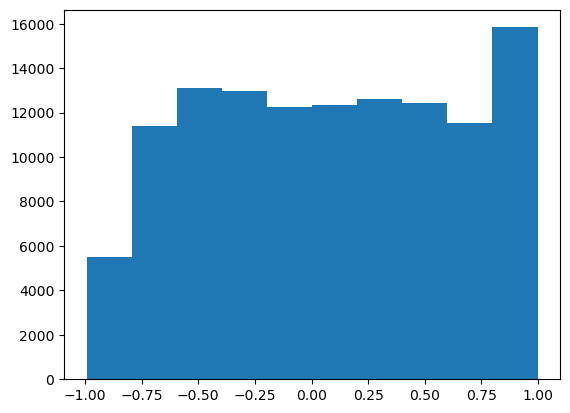

In [15]:
plt.hist(cosine_sim_scores)

In [16]:
ff_energy = ff_tau * q_vel
pd_energy = pd_tau * q_vel

dot_products = []

for ff_e, pd_e in zip(ff_energy, pd_energy):
    dot_products.append(np.dot(ff_e, pd_e))

dot_products = np.array(dot_products)

numerator = np.sum(np.maximum(-dot_products, 0.0))
denominator = np.sum(np.abs(dot_products))

metric = numerator/denominator

print("Fraction of Antagonistic Energy, ", np.round(metric, 4))

Fraction of Antagonistic Energy,  0.1404


In [17]:
total_energy = (ff_tau + pd_tau) * q_vel

numerator = np.abs(ff_energy) + np.abs(pd_energy) - np.abs(total_energy)
denominator = np.abs(ff_energy) + np.abs(pd_energy)

cancel_metric = np.mean(numerator) / np.mean(denominator)
print("Avg. Internal Power Cancellation - ", np.round(cancel_metric, 4))

Avg. Internal Power Cancellation -  0.1319


In [18]:
ratio = np.linalg.norm(pd_tau * q_vel) / np.linalg.norm(ff_tau * q_vel)
print("Avg. Coupled Torque Ratio - ", np.round(ratio, 4))

Avg. Coupled Torque Ratio -  0.3668
